In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.gan_model.neural_gan import NeuralGAN
from src.utils import function_collections as fc
from src.general_model.optimizer import Adam

rng = np.random.default_rng(519)

In [2]:
def f(x: np.ndarray) -> np.ndarray:
    return (
        (-1 + x**2) / (x**2 + 2.3)
        * np.log(np.sin(np.sqrt(2) * x) ** 2 + 3)
        * np.exp(np.sin(x))
    )


N_TRAIN = 10000
x_range = (-5.0, 10.0)
noise_x_std = 0.05
noise_y_std = 0.05
x_clean = rng.uniform(x_range[0], x_range[1], N_TRAIN)
y_clean = f(x_clean)

x_noisy = x_clean + noise_x_std * rng.normal(scale=noise_x_std, size=N_TRAIN)
y_noisy = y_clean + noise_y_std * rng.normal(scale=noise_y_std, size=N_TRAIN)

data = np.column_stack([x_noisy, y_noisy])

In [4]:
trainer = NeuralGAN(
    data_dim=2,
    latent_dim=4,
    hidden_layer=[32, 32],
    activation=fc.leaky_tanh,
    rand_gen=rng)

In [5]:
outcome, val_loss = trainer.train_model(data, 1000, 64, learning_rate=5e-4, validation_ratio=0.1, rand_gen=rng)

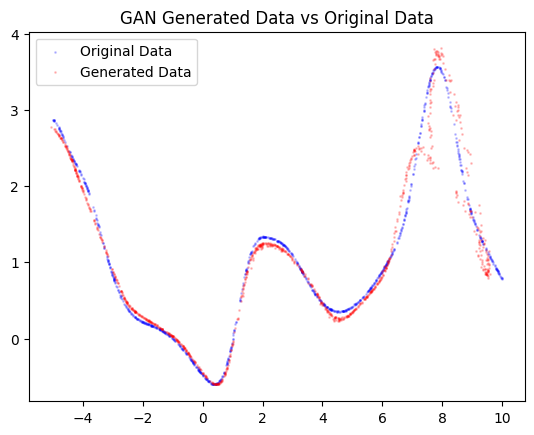

In [6]:
N_SAMPLES = 1000
generated_data = trainer.generate(N_SAMPLES)
original_samples = data[rng.choice(data.shape[0], N_SAMPLES, replace=False)]


plt.scatter(original_samples[:, 0], original_samples[:, 1],
            color='blue', label='Original Data', s=1, alpha=0.2)
plt.scatter(generated_data[:, 0], generated_data[:, 1],
            color='red', label='Generated Data', s=1, alpha=0.2)
plt.title('GAN Generated Data vs Original Data')
plt.legend()
plt.show()

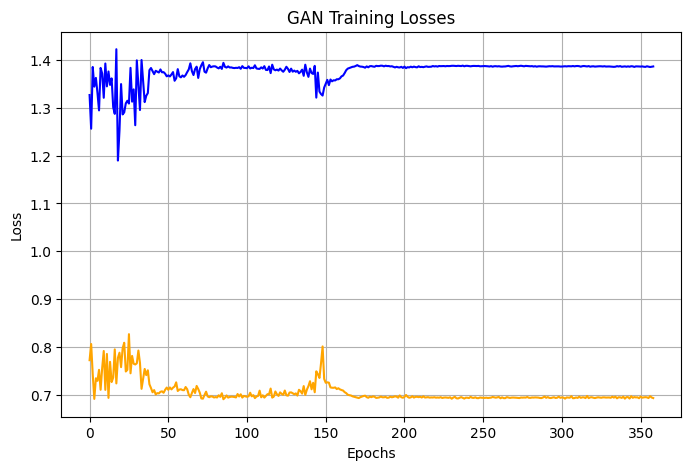

In [7]:
d_loss, g_loss = np.array(outcome).T
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_loss, label="Discriminator Loss", color='blue')
ax.plot(g_loss, label="Generator Loss", color='orange')
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.set_title("GAN Training Losses")
ax.grid(True)

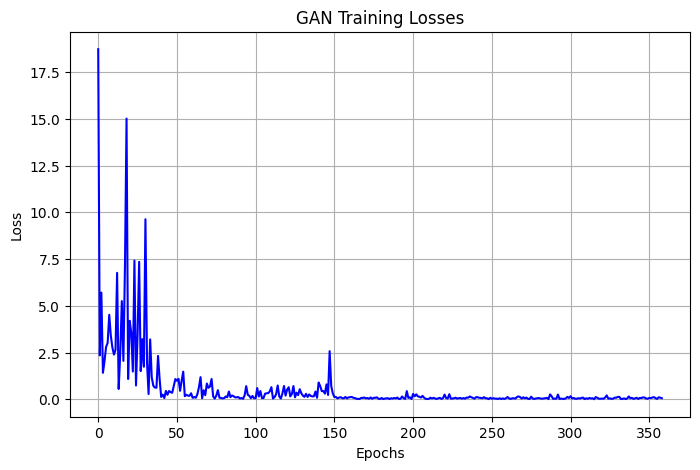

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(val_loss, label="Validation Loss", color='blue')
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.set_title("GAN Training Losses")
ax.grid(True)